In [24]:
import pandas as pd


In [25]:
# 读取合并的巴士收费表
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

file_path_1 = '../Data/Bus/Converted_Fare.xlsx'
df_converted_fare = pd.read_excel(file_path_1, engine='openpyxl')
df_converted_fare.head()

,ROUTE_ID,ROUTE_SEQ,ON_SEQ,OFF_SEQ,PRICE,LAST_UPDATE_DATE,ROUTE_NAMES,COMPANY_CODE,SERVICE_MODE,SPECIAL_TYPE,...,ON_SEQ_STOP_ID,STOP_SEQ_y,STOP_NAMES_y,OFF_SEQ_STOP_ID,ON_SEQ_STOP_X,ON_SEQ_STOP_Y,OFF_SEQ_STOP_X,OFF_SEQ_STOP_Y,ON_DISTRICT,OFF_DISTRICT
0,1001,1,1,2,6.7,2025-01-02,1,KMB,R,0,...,4001,2,天虹小学,4002,837872,822918,837621,822886,黃大仙,黃大仙
1,1001,1,1,3,6.7,2025-01-02,1,KMB,R,0,...,4001,3,马仔坑游乐场,4003,837872,822918,837391,822793,黃大仙,黃大仙
2,1001,1,1,4,6.7,2025-01-02,1,KMB,R,0,...,4001,4,摩士公园,4004,837872,822918,837557,822294,黃大仙,黃大仙
3,1001,1,1,5,6.7,2025-01-02,1,KMB,R,0,...,4001,5,摩士公园体育馆,4005,837872,822918,837610,822082,黃大仙,黃大仙
4,1001,1,1,6,6.7,2025-01-02,1,KMB,R,0,...,4001,6,伟东楼,4006,837872,822918,837768,821807,黃大仙,黃大仙


In [26]:
# 巴士票价与服务模式的关系
df_converted_fare['SERVICE_MODE'].unique()

array(['R', 'T', 'N', 'NT'], dtype=object)

e:\Users\非衣\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
e:\Users\非衣\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
e:\Users\非衣\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
e:\Users\非衣\AppData\Local\P

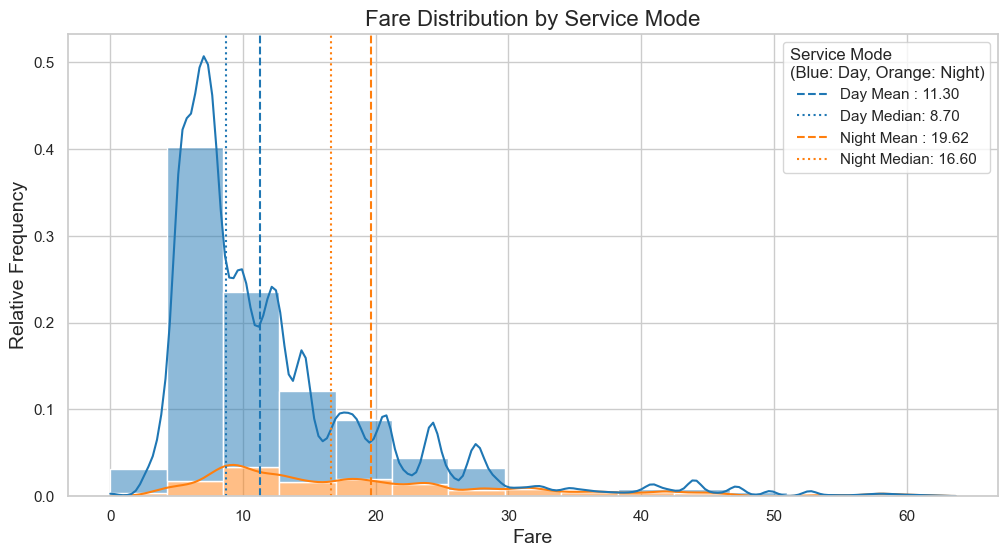

In [27]:
df_converted_fare['SERVICE_MODE'] = df_converted_fare['SERVICE_MODE'].replace({'N': 'Night', 'NT': 'Night', 'R': 'Day', 'T': 'Day'})

# 计算统计值
mode_stats = df_converted_fare.groupby('SERVICE_MODE')['PRICE'].agg(['mean', 'median', 'min', 'max']).reset_index()

# 设置绘图风格
sns.set(style='whitegrid')

# 创建直方图，纵坐标为相对频率
plt.figure(figsize=(12, 6))
palette = ['#1f77b4', '#ff7f0e']
sns.histplot(data=df_converted_fare, x='PRICE', bins=15, kde=True, hue='SERVICE_MODE', multiple='stack', alpha=0.5, palette=palette, stat='probability')

# 添加统计信息
for mode, color in zip(['Day', 'Night'], palette):
    mean_price = df_converted_fare[df_converted_fare['SERVICE_MODE'] == mode]['PRICE'].mean()
    median_price = df_converted_fare[df_converted_fare['SERVICE_MODE'] == mode]['PRICE'].median()
    
    plt.axvline(mean_price, linestyle='--', label=f'{mode} Mean : {mean_price:.2f}', color=color)
    plt.axvline(median_price, linestyle=':', label=f'{mode} Median: {median_price:.2f}', color=color)


# 添加标题和标签
plt.title('Fare Distribution by Service Mode', fontsize=16)
plt.xlabel('Fare', fontsize=14)
plt.ylabel('Relative Frequency', fontsize=14)

# 添加图例
plt.legend(title='Service Mode\n(Blue: Day, Orange: Night)')
plt.show()

In [28]:
# 读取人口普查表
file_path_2 = '../Data/Factors/DC_21C.csv'
df_factor = pd.read_csv(file_path_2).head(22)
df_factor.head()

,區議會分區（分組),區議會分區,區議會分區（英文名稱),區議會分區（中文名稱),總人口,按性別劃分的人口,按性別劃分的人口.1,性別比率（即男性數目與每千名女性相對的比率）,按年齡組別劃分的人口,按年齡組別劃分的人口.1,...,家庭住戶每月租金（港元）中位數,家庭住戶每月租金與收入比率中位數,家庭住戶的居所樓面面積中位數（平方米）(21),按5年前居住地區劃分的曾作內部遷移(22)的5歲及以上人口,按5年前居住地區劃分的曾作內部遷移(22)的5歲及以上人口.1,按5年前居住地區劃分的曾作內部遷移(22)的5歲及以上人口.2,按5年前居住地區劃分的曾作內部遷移(22)的5歲及以上人口.3,按5年前居住地區劃分的並無作內部遷移(22)的5歲及以上人口,按5年前居住地區劃分的並無作內部遷移(22)的5歲及以上人口.1,按5年前居住地區劃分的並無作內部遷移(22)的5歲及以上人口.2
0,District Council district (class),District Council district,Name of District Council district (in English),Name of District Council district (in Chinese),Total population,Population by sex,Population by sex,Sex ratio (i.e. the number of males per 1 000 ...,Population by age group,Population by age group,...,Median monthly domestic household rent (HK$),Median monthly domestic household rent to inco...,Median floor area of accommodation of domestic...,Population aged 5 and over having internally m...,Population aged 5 and over having internally m...,Population aged 5 and over having internally m...,Population aged 5 and over having internally m...,Population aged 5 and over not having internal...,Population aged 5 and over not having internal...,Population aged 5 and over not having internal...
1,區議會分區（分組),區議會分區,區議會分區（英文名稱),區議會分區（中文名稱),總人口,男性,女性,性別比率（即男性數目與每千名女性相對的比率）,15歲以下,15至24歲,...,家庭住戶每月租金（港元）中位數,家庭住戶每月租金與收入比率中位數,家庭住戶的居所樓面面積中位數（平方米）(21),香港島,九龍,新市鎮,新界其他地區／水上,曾在同區遷居,仍居舊址(23),居於香港以外地方
2,District Council district (class),District Council district,Name of District Council district (in English),Name of District Council district (in Chinese),Total population,Male,Female,Sex ratio (i.e. the number of males per 1 000 ...,< 15,15 - 24,...,Median monthly domestic household rent (HK$),Median monthly domestic household rent to inco...,Median floor area of accommodation of domestic...,Hong Kong Island,Kowloon,New towns,Other areas in the New Territories/ Marine,Moved home within same area of residence,Remained in same address(23),Place of residence outside Hong Kong
3,dc_class,dc,dc_eng,dc_chi,t_pop,pop_m,pop_f,sr,age_1,age_2,...,dm_r,dmr_ir,fa_m,pm_hk,pm_kln,pm_nt,pm_oth,pm_samearea,pm_same,pm_out
4,A,11,Central and Western,中西區,235953,98282,137671,714,24382,16779,...,15070,28,41,9932,5408,5799,1562,26614,153665,25390


In [29]:
# 添加cost index列
df_factor = df_factor.drop(index=[0, 1, 2, 3]).reset_index(drop=True)
df_factor['cost index'] = np.array([1.849309494,
3.075867121,
4.276393649,
5.492740232,
1.978903615,
5.082911945,
3.818203774,
2.114631448,
2.58581934,
2.169578909,
2.955856735,
1.776562612,
3.694651284,
2.218062621,
5.574087662,
2.01012663,
2.117823541,
3.17919441])
df_factor.head()

,區議會分區（分組),區議會分區,區議會分區（英文名稱),區議會分區（中文名稱),總人口,按性別劃分的人口,按性別劃分的人口.1,性別比率（即男性數目與每千名女性相對的比率）,按年齡組別劃分的人口,按年齡組別劃分的人口.1,...,家庭住戶每月租金與收入比率中位數,家庭住戶的居所樓面面積中位數（平方米）(21),按5年前居住地區劃分的曾作內部遷移(22)的5歲及以上人口,按5年前居住地區劃分的曾作內部遷移(22)的5歲及以上人口.1,按5年前居住地區劃分的曾作內部遷移(22)的5歲及以上人口.2,按5年前居住地區劃分的曾作內部遷移(22)的5歲及以上人口.3,按5年前居住地區劃分的並無作內部遷移(22)的5歲及以上人口,按5年前居住地區劃分的並無作內部遷移(22)的5歲及以上人口.1,按5年前居住地區劃分的並無作內部遷移(22)的5歲及以上人口.2,cost index
0,A,11,Central and Western,中西區,235953,98282,137671,714,24382,16779,...,28,41,9932,5408,5799,1562,26614,153665,25390,1.849309
1,B,12,Wan Chai,灣仔區,166695,67075,99620,673,16917,9907,...,28.1,47,11587,4978,4826,1132,17262,104927,16873,3.075867
2,C,13,Eastern,東區,529603,233542,296061,789,51517,36336,...,19.3,44,15299,8426,10529,2079,46515,406489,26276,4.276394
3,D,14,Southern,南區,263278,116239,147039,791,27255,18842,...,15.7,41,10450,4560,4128,1508,20782,200203,14426,5.492740
4,E,27,Yau Tsim Mong,油尖旺區,310647,138873,171774,808,36181,23224,...,32,37,6925,14591,13189,2361,32320,197542,31863,1.978904


e:\Users\非衣\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 32317 (\N{CJK UNIFIED IDEOGRAPH-7E3D}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
e:\Users\非衣\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 20154 (\N{CJK UNIFIED IDEOGRAPH-4EBA}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
e:\Users\非衣\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 21475 (\N{CJK UNIFIED IDEOGRAPH-53E3}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
e:\Users\非衣\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\pylabtools.py:152: UserWarning: Glyph 25353 (\N{CJK UNIFIED IDEOGRAPH-6309}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
e:\Users\非衣\AppData\Local\Programs\Python\Python311\Lib\site-packages\IPython\core\p

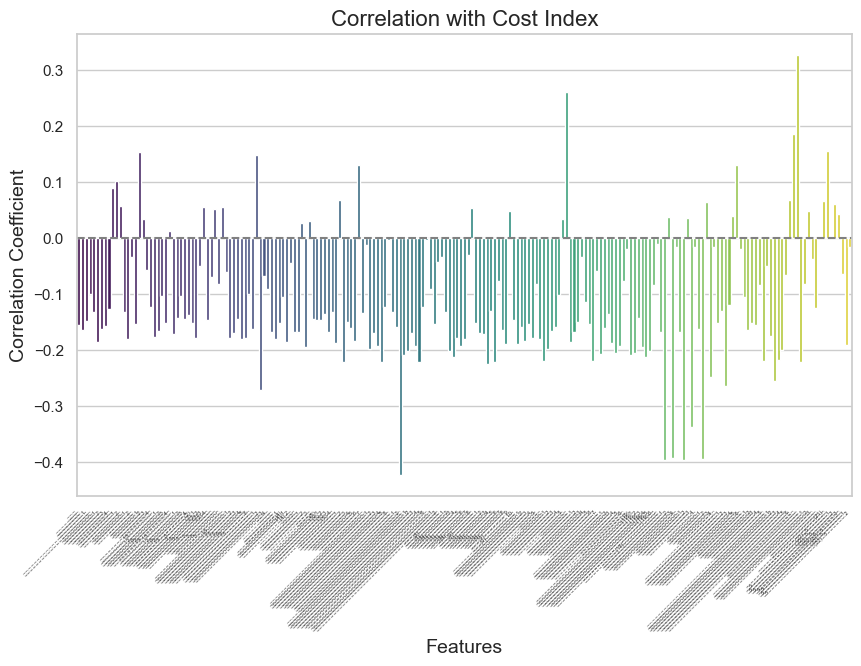

In [30]:
# 可视化人口普查数据与cost index的关系
df_factor_district=df_factor.copy()
df_factor = df_factor.iloc[:, 4:]
df_factor = df_factor.apply(pd.to_numeric, errors='coerce')
correlation_matrix = df_factor.corr()

# 提取与 'cost index' 列的相关系数
cost_index_correlation = correlation_matrix['cost index'].drop('cost index')

# 可视化相关系数
plt.figure(figsize=(10, 6))
sns.barplot(x=cost_index_correlation.index, y=cost_index_correlation.values, palette='viridis')
plt.title('Correlation with Cost Index', fontsize=16)
plt.xlabel('Features', fontsize=14)
plt.ylabel('Correlation Coefficient', fontsize=14)
plt.xticks(rotation=45, ha='right',  fontsize=4)
plt.axhline(0, color='gray', linestyle='--')
plt.show()

In [31]:
sorted_correlation = cost_index_correlation.abs().sort_values(ascending=False)

# 列出前20个字段
top_20_fields = sorted_correlation.head(20)
top_20_columns = top_20_fields.index.tolist()

# 将 '區議會分區（中文名稱)' 和 top_20_fields 的字段组合成一个新的 DataFrame
selected_columns = ['區議會分區（中文名稱)'] + top_20_columns
df_filtered_factor = df_factor_district[selected_columns]
df_filtered_factor['區議會分區（中文名稱)']=np.array(['中西區', '灣仔', '東區', '南區', '油尖旺', '深水埗', '九龍城', '黃大仙', '觀塘', '葵青', '荃灣', '屯門', '元朗'
                                 , '北區', '大埔', '沙田', '西貢', '離島'])
df_filtered_factor.head()

C:\Users\非衣\AppData\Local\Temp\ipykernel_117196\2730767462.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtered_factor['區議會分區（中文名稱)']=np.array(['中西區', '灣仔', '東區', '南區', '油尖旺', '深水埗', '九龍城', '黃大仙', '觀塘', '葵青', '荃灣', '屯門', '元朗'


,區議會分區（中文名稱),按性別劃分的每月主要職業收入（港元）中位數（不包括無酬家庭從業員）.2,按房屋類型劃分的有人居住的屋宇單位數目.1,按房屋類型劃分的家庭住戶數目.1,按房屋類型劃分的人口.1,按房屋類型劃分的有人居住的屋宇單位數目.3,按房屋類型劃分的家庭住戶數目.3,家庭住戶每月按揭供款及借貸還款與收入比率中位數,按上課地點劃分的於香港院校就讀全日制課程的人口.2,按廳房數目﹝不包括廚房及廁所﹞劃分的家庭住戶數目.2,...,按家庭住戶每月按揭供款及借貸還款（港元）劃分的有按揭供款或借貸還款的家庭住戶數目.2,按房屋類型劃分的人口.3,按行業(9)劃分的工作人口.3,按家庭住戶每月租金（港元）劃分的居於租住居所的家庭住戶數目,按行業(9)劃分的工作人口.5,按工作地點劃分的工作人口.2,按每月主要職業收入（港元）劃分的工作人口（不包括無酬家庭從業員）.4,按每月主要職業收入（港元）劃分的工作人口（不包括外籍家庭傭工及無酬家庭從業員）.4,按住戶人數劃分的家庭住戶數目,按住戶結構劃分的家庭住戶數目.6
0,中西區,17000,-,-,-,2331,1572,21.3,3224,33384,...,522,4697,5504,2791,4815,16916,12189,12189,24464,24464
1,灣仔,15000,-,-,-,407,293,21.4,1799,20369,...,211,1632,2807,2496,4532,10759,7238,7238,17579,17579
2,東區,15500,28633,28628,83062,532,360,20,6748,71213,...,1657,3057,15233,14475,11145,43826,24868,24868,35769,35769
3,南區,13000,15775,15727,43538,955,535,20,2705,31423,...,1087,7087,9469,12426,3934,16557,11214,11214,13627,13627
4,油尖旺,15000,4081,4081,12138,4124,4066,22.8,13473,44373,...,1386,9562,8813,2672,5707,23661,14637,14637,37041,37041


In [32]:
# 清洗空列
df_filtered_factor=df_filtered_factor.drop(columns=['按房屋類型劃分的有人居住的屋宇單位數目.1','按房屋類型劃分的家庭住戶數目.1','按房屋類型劃分的人口.1'])

In [33]:
# 合并巴士数据与特征数据
BUS_FE=pd.read_excel('../Data/BUS/SelectedRoute.xlsx',engine='openpyxl')
merged_df = pd.merge(BUS_FE, df_filtered_factor, how='left', left_on='ON_DISTRICT', right_on='區議會分區（中文名稱)')

Selected_factors=pd.read_excel('../Data/Factors/Selected_factors.xlsx',engine='openpyxl')
merged_df=pd.merge(merged_df,Selected_factors,how='left',left_on='ON_DISTRICT',right_on='區議會分區')
merged_df.head()

,Unnamed: 0,ROUTE_ID,ROUTE_SEQ,ON_SEQ,OFF_SEQ,PRICE,ROUTE_NAMES,COMPANY_CODE,SERVICE_MODE,SPECIAL_TYPE,...,MEAN_COST_INDEX,Income(Median),Area,Population,Male Population,Female Population,Gender Ratio,Population Density,Num_Bus_Stop,Bus Stop Density
0,271,1001,1,17,25,5.8,1,KMB,R,0,...,2.169579,18000,6.99,310647,138873,171774,808,44441.630901,210,30.042918
1,152,1001,1,8,14,6.7,1,KMB,R,0,...,3.075867,18000,10.01,410634,179518,231116,777,41022.377622,247,24.675325
2,254,1001,1,15,25,6.7,1,KMB,R,0,...,2.169579,18000,6.99,310647,138873,171774,808,44441.630901,210,30.042918
3,5,1001,1,1,7,6.7,1,KMB,R,0,...,3.179194,16000,9.30,406802,187531,219271,855,43742.150538,152,16.344086
4,525,1001,2,13,17,6.3,1,KMB,R,0,...,3.075867,18000,10.01,410634,179518,231116,777,41022.377622,247,24.675325


In [34]:
merged_df.to_excel("../Data/BUS/Bus_FE.xlsx",engine="openpyxl")

In [35]:
# 读取选定巴士数据
file_path_3 = '../Data/Bus/SelectedRoute.xlsx'
df_select = pd.read_excel(file_path_3, engine='openpyxl')
df_select.head()

,Unnamed: 0,ROUTE_ID,ROUTE_SEQ,ON_SEQ,OFF_SEQ,PRICE,ROUTE_NAMES,COMPANY_CODE,SERVICE_MODE,SPECIAL_TYPE,...,STOP_NAMES_y,OFF_SEQ_STOP_ID,ON_STOP_X,ON_STOP_Y,OFF_STOP_X,OFF_STOP_Y,ON_DISTRICT,OFF_DISTRICT,DISTANCE,COST_INDEX
0,271,1001,1,17,25,5.8,1,KMB,R,0,...,尖沙咀码头,4025,835531,819900,835463,817244,油尖旺,油尖旺,2724,0.024715
1,152,1001,1,8,14,6.7,1,KMB,R,0,...,拔萃男书院,4014,837429,821474,836023,820663,九龍城,九龍城,2217,0.023813
2,254,1001,1,15,25,6.7,1,KMB,R,0,...,尖沙咀码头,4025,835862,820632,835463,817244,油尖旺,油尖旺,3787,0.039692
3,5,1001,1,1,7,6.7,1,KMB,R,0,...,盈东楼,8090,837872,822918,837727,821666,黃大仙,黃大仙,1397,0.025438
4,525,1001,2,13,17,6.3,1,KMB,R,0,...,东宝庭道,4039,836322,820884,837258,821296,九龍城,九龍城,1348,0.013615


In [36]:
# 选定所需的列
df_select = df_select[['ROUTE_ID', 'ROUTE_SEQ', 'ON_SEQ', 'OFF_SEQ', 'PRICE', 'COMPANY_CODE', 'SERVICE_MODE', 'SPECIAL_TYPE', 'ON_DISTRICT', 'OFF_DISTRICT', 'DISTANCE']]
df_select.head()

,ROUTE_ID,ROUTE_SEQ,ON_SEQ,OFF_SEQ,PRICE,COMPANY_CODE,SERVICE_MODE,SPECIAL_TYPE,ON_DISTRICT,OFF_DISTRICT,DISTANCE
0,1001,1,17,25,5.8,KMB,R,0,油尖旺,油尖旺,2724
1,1001,1,8,14,6.7,KMB,R,0,九龍城,九龍城,2217
2,1001,1,15,25,6.7,KMB,R,0,油尖旺,油尖旺,3787
3,1001,1,1,7,6.7,KMB,R,0,黃大仙,黃大仙,1397
4,1001,2,13,17,6.3,KMB,R,0,九龍城,九龍城,1348


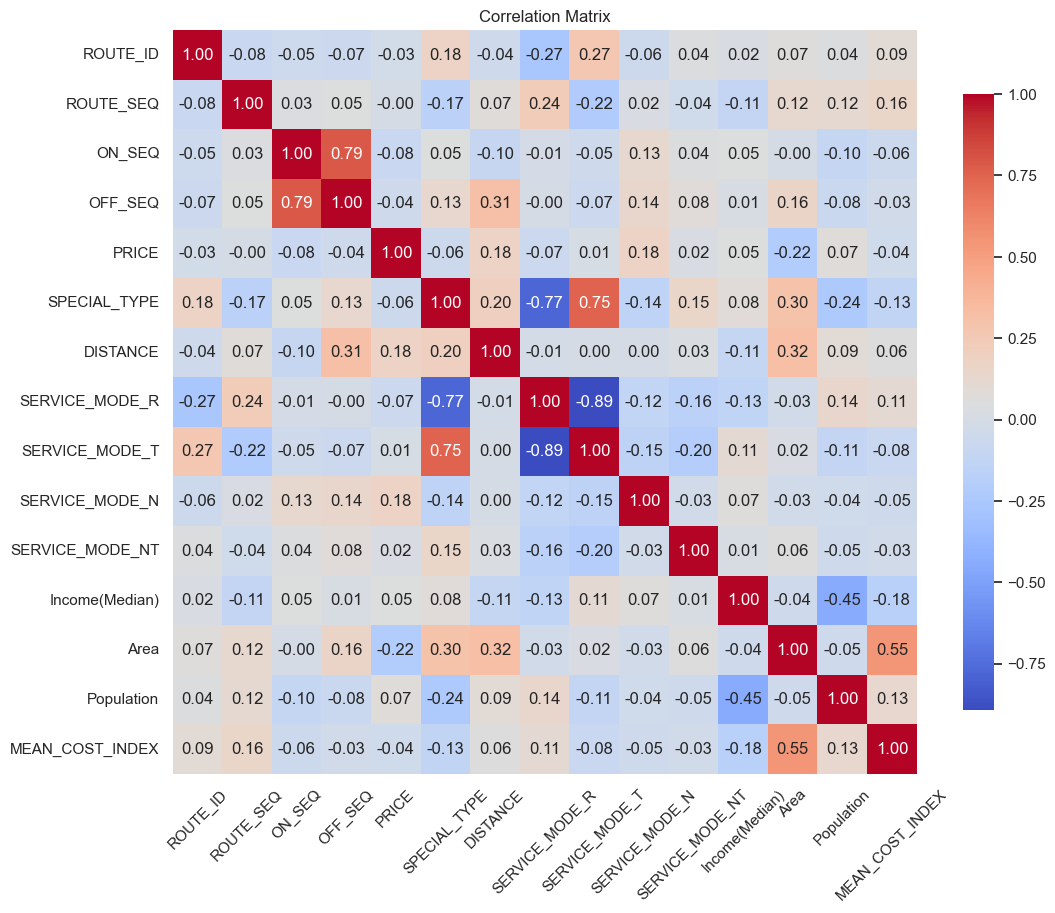

In [37]:
# 绘制热力图
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df_select['SERVICE_MODE_R'] = np.where(df_select['SERVICE_MODE'] == 'R', 1, 0)
df_select['SERVICE_MODE_T'] = np.where(df_select['SERVICE_MODE'] == 'T', 1, 0)
df_select['SERVICE_MODE_N'] = np.where(df_select['SERVICE_MODE'] == 'N', 1, 0)
df_select['SERVICE_MODE_NT'] = np.where(df_select['SERVICE_MODE'] == 'NT', 1, 0)

file_path_4 = '../Data/Factors/Selected_factors.xlsx'
df_selected_factors = pd.read_excel(file_path_4, engine='openpyxl')
result = pd.merge(df_select, df_selected_factors, left_on = 'ON_DISTRICT', right_on = '區議會分區', how = 'left')


result = result[['ROUTE_ID', 'ROUTE_SEQ', 'ON_SEQ', 'OFF_SEQ', 'PRICE', 'SPECIAL_TYPE', 'DISTANCE', 'SERVICE_MODE_R', 'SERVICE_MODE_T', 'SERVICE_MODE_N', 'SERVICE_MODE_NT', 'Income(Median)', 'Area', 'Population', 'MEAN_COST_INDEX']]



correlation_matrix = result.corr()


plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, cbar_kws={"shrink": .8})
plt.title('Correlation Matrix')
plt.xticks(rotation=45)


plt.show() 

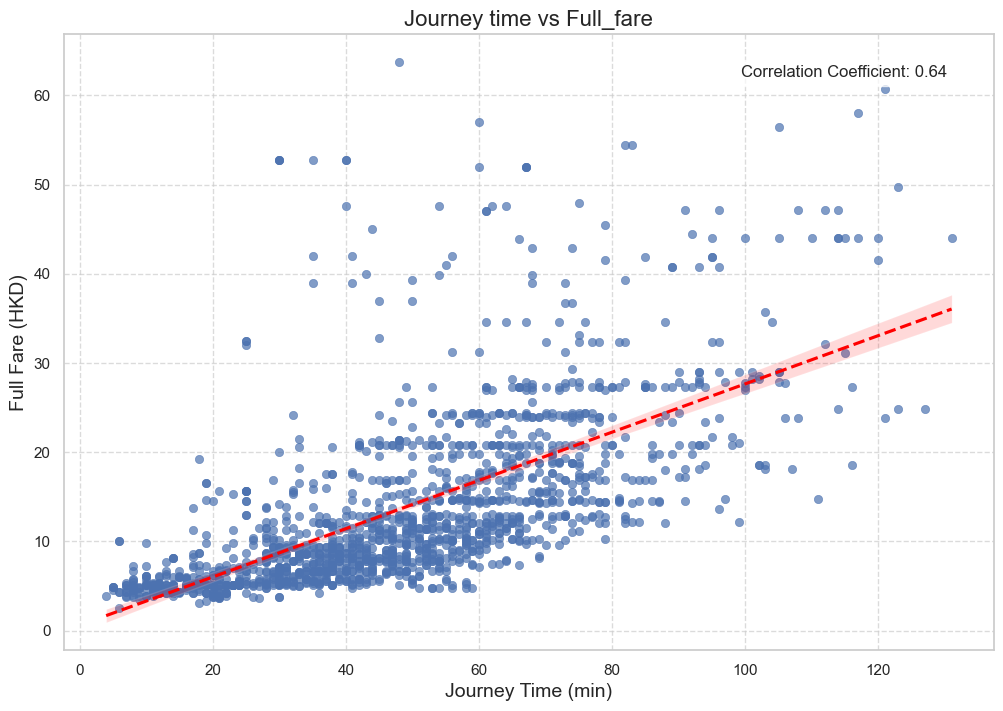

In [38]:
# Journey time与Full fare的关系
file_path_5 = '../Data/Bus/ROUTE.xlsx'
df_route = pd.read_excel(file_path_5, engine='openpyxl')
correlation_coeff = df_route['JOURNEY_TIME'].corr(df_route['FULL_FARE'])

plt.figure(figsize=(12, 8))  
sns.scatterplot(data=df_route, x='JOURNEY_TIME', y='FULL_FARE', alpha=0.7, edgecolor=None)

# 添加回归线
sns.regplot(data=df_route, x='JOURNEY_TIME', y='FULL_FARE', scatter=False, color='red', line_kws={"linestyle": "--"})

# 设置标题和标签
plt.title('Journey time vs Full_fare', fontsize=16)
plt.xlabel('Journey Time (min)', fontsize=14)
plt.ylabel('Full Fare (HKD)', fontsize=14)

plt.text(0.95, 0.95, f'Correlation Coefficient: {correlation_coeff:.2f}', 
         horizontalalignment='right', verticalalignment='top', 
         transform=plt.gca().transAxes, fontsize=12, bbox=dict(facecolor='white', alpha=0.7))


# 添加网格
plt.grid(True, linestyle='--', alpha=0.7)

# 显示图形
plt.show()

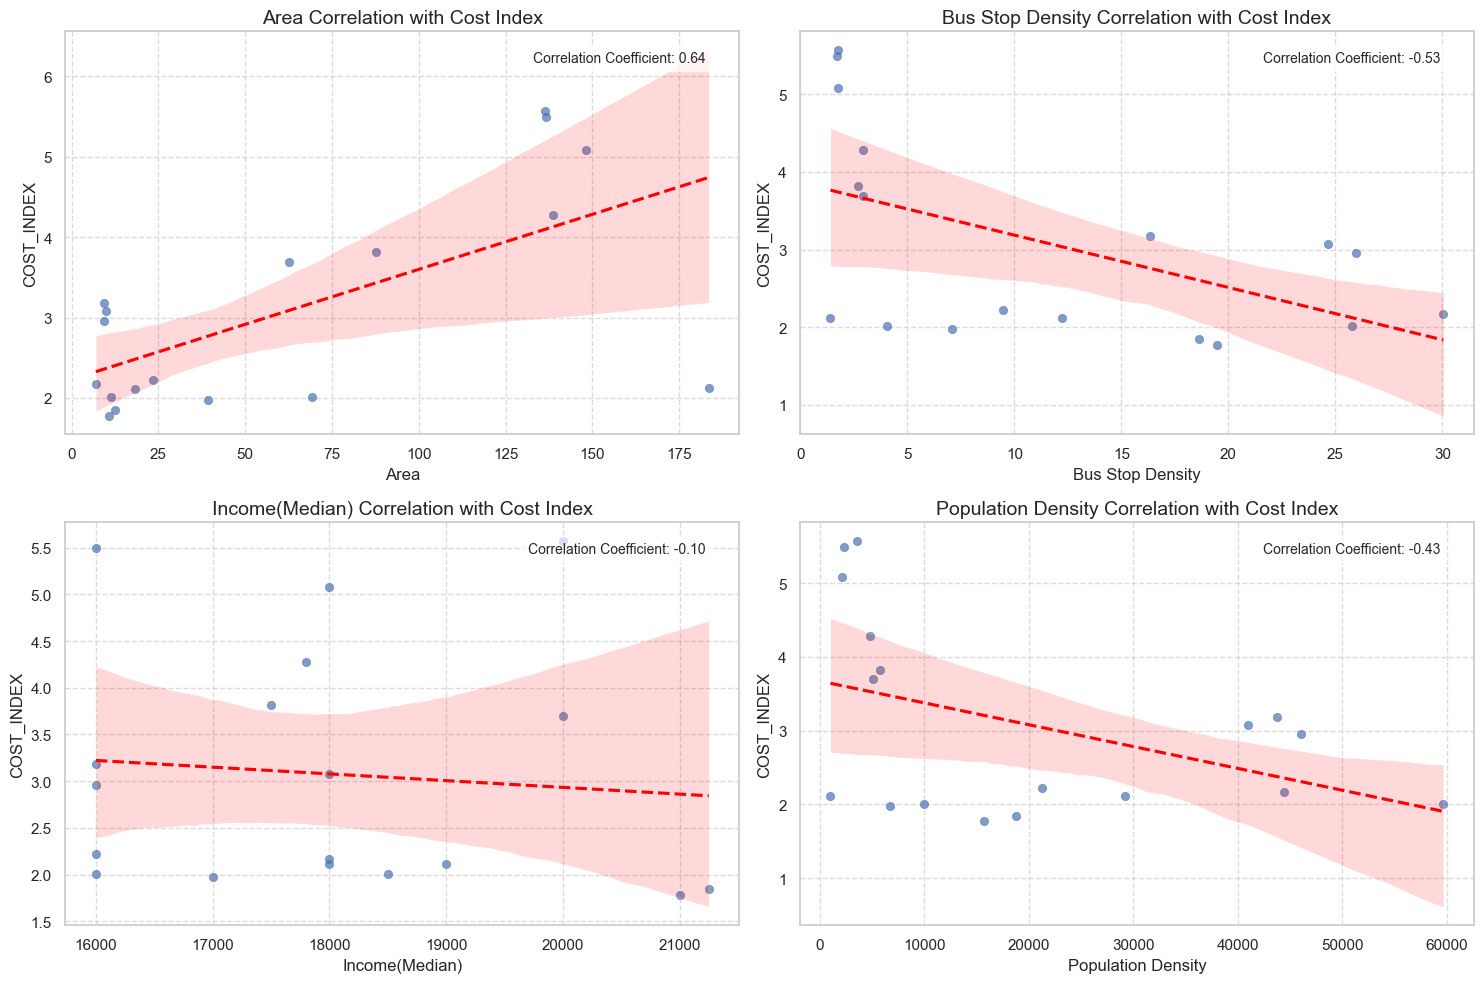

In [39]:
variables = ['Area', 'Bus Stop Density', 'Income(Median)', 'Population Density']

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.flatten()  # 将 2D 数组展平，以便迭代

# 绘制每个变量与 COST_INDEX 的关系
for i, var in enumerate(variables):
    # 计算相关系数
    correlation_coeff = df_selected_factors['MEAN_COST_INDEX'].corr(df_selected_factors[var])
    
    # 绘制散点图
    sns.scatterplot(data=df_selected_factors, x=var, y='MEAN_COST_INDEX', ax=axes[i], alpha=0.7, edgecolor=None)
    
    # 添加回归线
    sns.regplot(data=df_selected_factors, x=var, y='MEAN_COST_INDEX', ax=axes[i], scatter=False, color='red', line_kws={"linestyle": "--"})
    
    # 设置标题和标签
    axes[i].set_title(f'{var} Correlation with Cost Index', fontsize=14)
    axes[i].set_xlabel(var, fontsize=12)
    axes[i].set_ylabel('COST_INDEX', fontsize=12)
    
    # 添加网格
    axes[i].grid(True, linestyle='--', alpha=0.7)
    
    # 在右上角添加相关系数标签
    axes[i].text(0.95, 0.95, f'Correlation Coefficient: {correlation_coeff:.2f}', 
                 horizontalalignment='right', verticalalignment='top', 
                 transform=axes[i].transAxes, fontsize=10, bbox=dict(facecolor='white', alpha=0.7))

# 调整布局
plt.tight_layout()
plt.show()